# 05 — Bias Audit

**Mandatory before any deployment claim.**

A model that disproportionately flags students from certain demographic groups — even with identical behavioral profiles — creates harm and legal liability.

**Checks:**
- **FPR parity:** False positive rate should not differ by > 5 percentage points across groups
- **TPR parity:** True positive rate (recall) should be consistent — model catches at-risk students equally across groups
- **Disparate impact:** Positive prediction rate ratio across groups — flag if any group is predicted at-risk > 1.25× another

**Primary axes:** gender, age_band, imd_band (deprivation — strongest signal from EDA)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
FIG_DIR = Path('../docs/figures')

FPR_THRESHOLD = 0.05   # max acceptable FPR gap between groups
DI_THRESHOLD  = 1.25   # disparate impact flag threshold

## Load Predictions and Demographics

In [2]:
preds = pd.read_csv('../data/output/predictions.csv')
info  = pd.read_csv('../data/raw/studentInfo.csv',
                    usecols=['code_module', 'code_presentation', 'id_student',
                             'gender', 'age_band', 'imd_band', 'disability'])

df = preds.merge(info, on=['code_module', 'code_presentation', 'id_student'], how='left')
print(f'Merged: {df.shape}')
print(f'Nulls in demographic cols: {df[["gender","age_band","imd_band"]].isnull().sum().to_dict()}')

Merged: (32593, 16)
Nulls in demographic cols: {'gender': 0, 'age_band': 0, 'imd_band': 1111}


## Fairness Metrics Function

In [3]:
def fairness_metrics(df, group_col, threshold=0.5):
    """Compute FPR, TPR, PPR, and counts per group."""
    rows = []
    df = df.dropna(subset=[group_col])
    pred_col = 'predicted_label'
    true_col = 'true_label'

    for group, gdf in df.groupby(group_col, observed=True):
        tp = ((gdf[pred_col] == 1) & (gdf[true_col] == 1)).sum()
        fp = ((gdf[pred_col] == 1) & (gdf[true_col] == 0)).sum()
        tn = ((gdf[pred_col] == 0) & (gdf[true_col] == 0)).sum()
        fn = ((gdf[pred_col] == 0) & (gdf[true_col] == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        ppr = (tp + fp) / len(gdf)  # positive prediction rate
        rows.append({
            'group': str(group), 'n': len(gdf),
            'n_withdrawn': int(gdf[true_col].sum()),
            'actual_withdrawal_rate': round(gdf[true_col].mean(), 4),
            'fpr': round(fpr, 4), 'tpr': round(tpr, 4), 'ppr': round(ppr, 4),
            'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        })
    return pd.DataFrame(rows).set_index('group')


def flag_disparities(metrics_df, col, threshold, label):
    values = metrics_df[col].dropna()
    gap = values.max() - values.min()
    flag = '⚠️ FLAGGED' if gap > threshold else '✓ OK'
    print(f'{label}: max={values.max():.4f} min={values.min():.4f} gap={gap:.4f}  →  {flag}')
    return gap > threshold

## Audit by Gender

In [4]:
gender_metrics = fairness_metrics(df, 'gender')
display(gender_metrics)
flag_disparities(gender_metrics, 'fpr', FPR_THRESHOLD, 'FPR gap (gender)')
di_ratio_gender = gender_metrics['ppr'].max() / gender_metrics['ppr'].min()
print(f'Disparate impact ratio (gender): {di_ratio_gender:.3f}  →  {"⚠️ FLAGGED" if di_ratio_gender > DI_THRESHOLD else "✓ OK"}')

,n,n_withdrawn,actual_withdrawal_rate,fpr,tpr,ppr,tp,fp,tn,fn
group,,,,,,,,,,
F,14718,4486,0.3048,0.0572,0.6146,0.2271,2757,585,9647,1729
M,17875,5670,0.3172,0.0651,0.6086,0.2375,3451,795,11410,2219


FPR gap (gender): max=0.0651 min=0.0572 gap=0.0079  →  ✓ OK
Disparate impact ratio (gender): 1.046  →  ✓ OK


## Audit by Age Band

In [5]:
age_metrics = fairness_metrics(df, 'age_band')
display(age_metrics)
flag_disparities(age_metrics, 'fpr', FPR_THRESHOLD, 'FPR gap (age_band)')
di_ratio_age = age_metrics['ppr'].max() / age_metrics['ppr'].min()
print(f'Disparate impact ratio (age_band): {di_ratio_age:.3f}  →  {"⚠️ FLAGGED" if di_ratio_age > DI_THRESHOLD else "✓ OK"}')

,n,n_withdrawn,actual_withdrawal_rate,fpr,tpr,ppr,tp,fp,tn,fn
group,,,,,,,,,,
0-35,22944,7381,0.3217,0.0664,0.6228,0.2454,4597,1034,14529,2784
35-55,9433,2721,0.2885,0.0511,0.5807,0.2039,1580,343,6369,1141
55<=,216,54,0.2500,0.0185,0.5741,0.1574,31,3,159,23


FPR gap (age_band): max=0.0664 min=0.0185 gap=0.0479  →  ✓ OK
Disparate impact ratio (age_band): 1.559  →  ⚠️ FLAGGED


## Audit by IMD Band (Primary Axis)

IMD = Index of Multiple Deprivation. EDA showed this has the highest demographic disparity in withdrawal rates — most important axis for bias audit.

In [6]:
imd_metrics = fairness_metrics(df, 'imd_band')
display(imd_metrics)
flag_disparities(imd_metrics, 'fpr', FPR_THRESHOLD, 'FPR gap (imd_band)')
di_ratio_imd = imd_metrics['ppr'].max() / imd_metrics['ppr'].min()
print(f'Disparate impact ratio (imd_band): {di_ratio_imd:.3f}  →  {"⚠️ FLAGGED" if di_ratio_imd > DI_THRESHOLD else "✓ OK"}')

,n,n_withdrawn,actual_withdrawal_rate,fpr,tpr,ppr,tp,fp,tn,fn
group,,,,,,,,,,
0-10%,3311,1231,0.3718,0.0981,0.6450,0.3014,794,204,1876,437
10-20,3516,1246,0.3544,0.0806,0.6453,0.2807,804,183,2087,442
20-30%,3654,1321,0.3615,0.0840,0.6336,0.2827,837,196,2137,484
30-40%,3539,1095,0.3094,0.0606,0.6027,0.2283,660,148,2296,435
40-50%,3256,1042,0.3200,0.0637,0.6200,0.2417,646,141,2073,396
50-60%,3124,899,0.2878,0.0544,0.6118,0.2148,550,121,2104,349
60-70%,2905,859,0.2957,0.0557,0.5658,0.2065,486,114,1932,373
70-80%,2879,797,0.2768,0.0504,0.5822,0.1976,464,105,1977,333
80-90%,2762,774,0.2802,0.0418,0.6034,0.1991,467,83,1905,307


FPR gap (imd_band): max=0.0981 min=0.0351 gap=0.0630  →  ⚠️ FLAGGED
Disparate impact ratio (imd_band): 1.702  →  ⚠️ FLAGGED


## Visualise Bias Metrics

C:\Users\jeged\AppData\Local\Temp\ipykernel_449452\3082218494.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
C:\Users\jeged\AppData\Local\Temp\ipykernel_449452\3082218494.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
C:\Users\jeged\AppData\Local\Temp\ipykernel_449452\3082218494.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
C:\Users\jeged\AppData\Local\Temp\ipykernel_449452\3082218494.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  

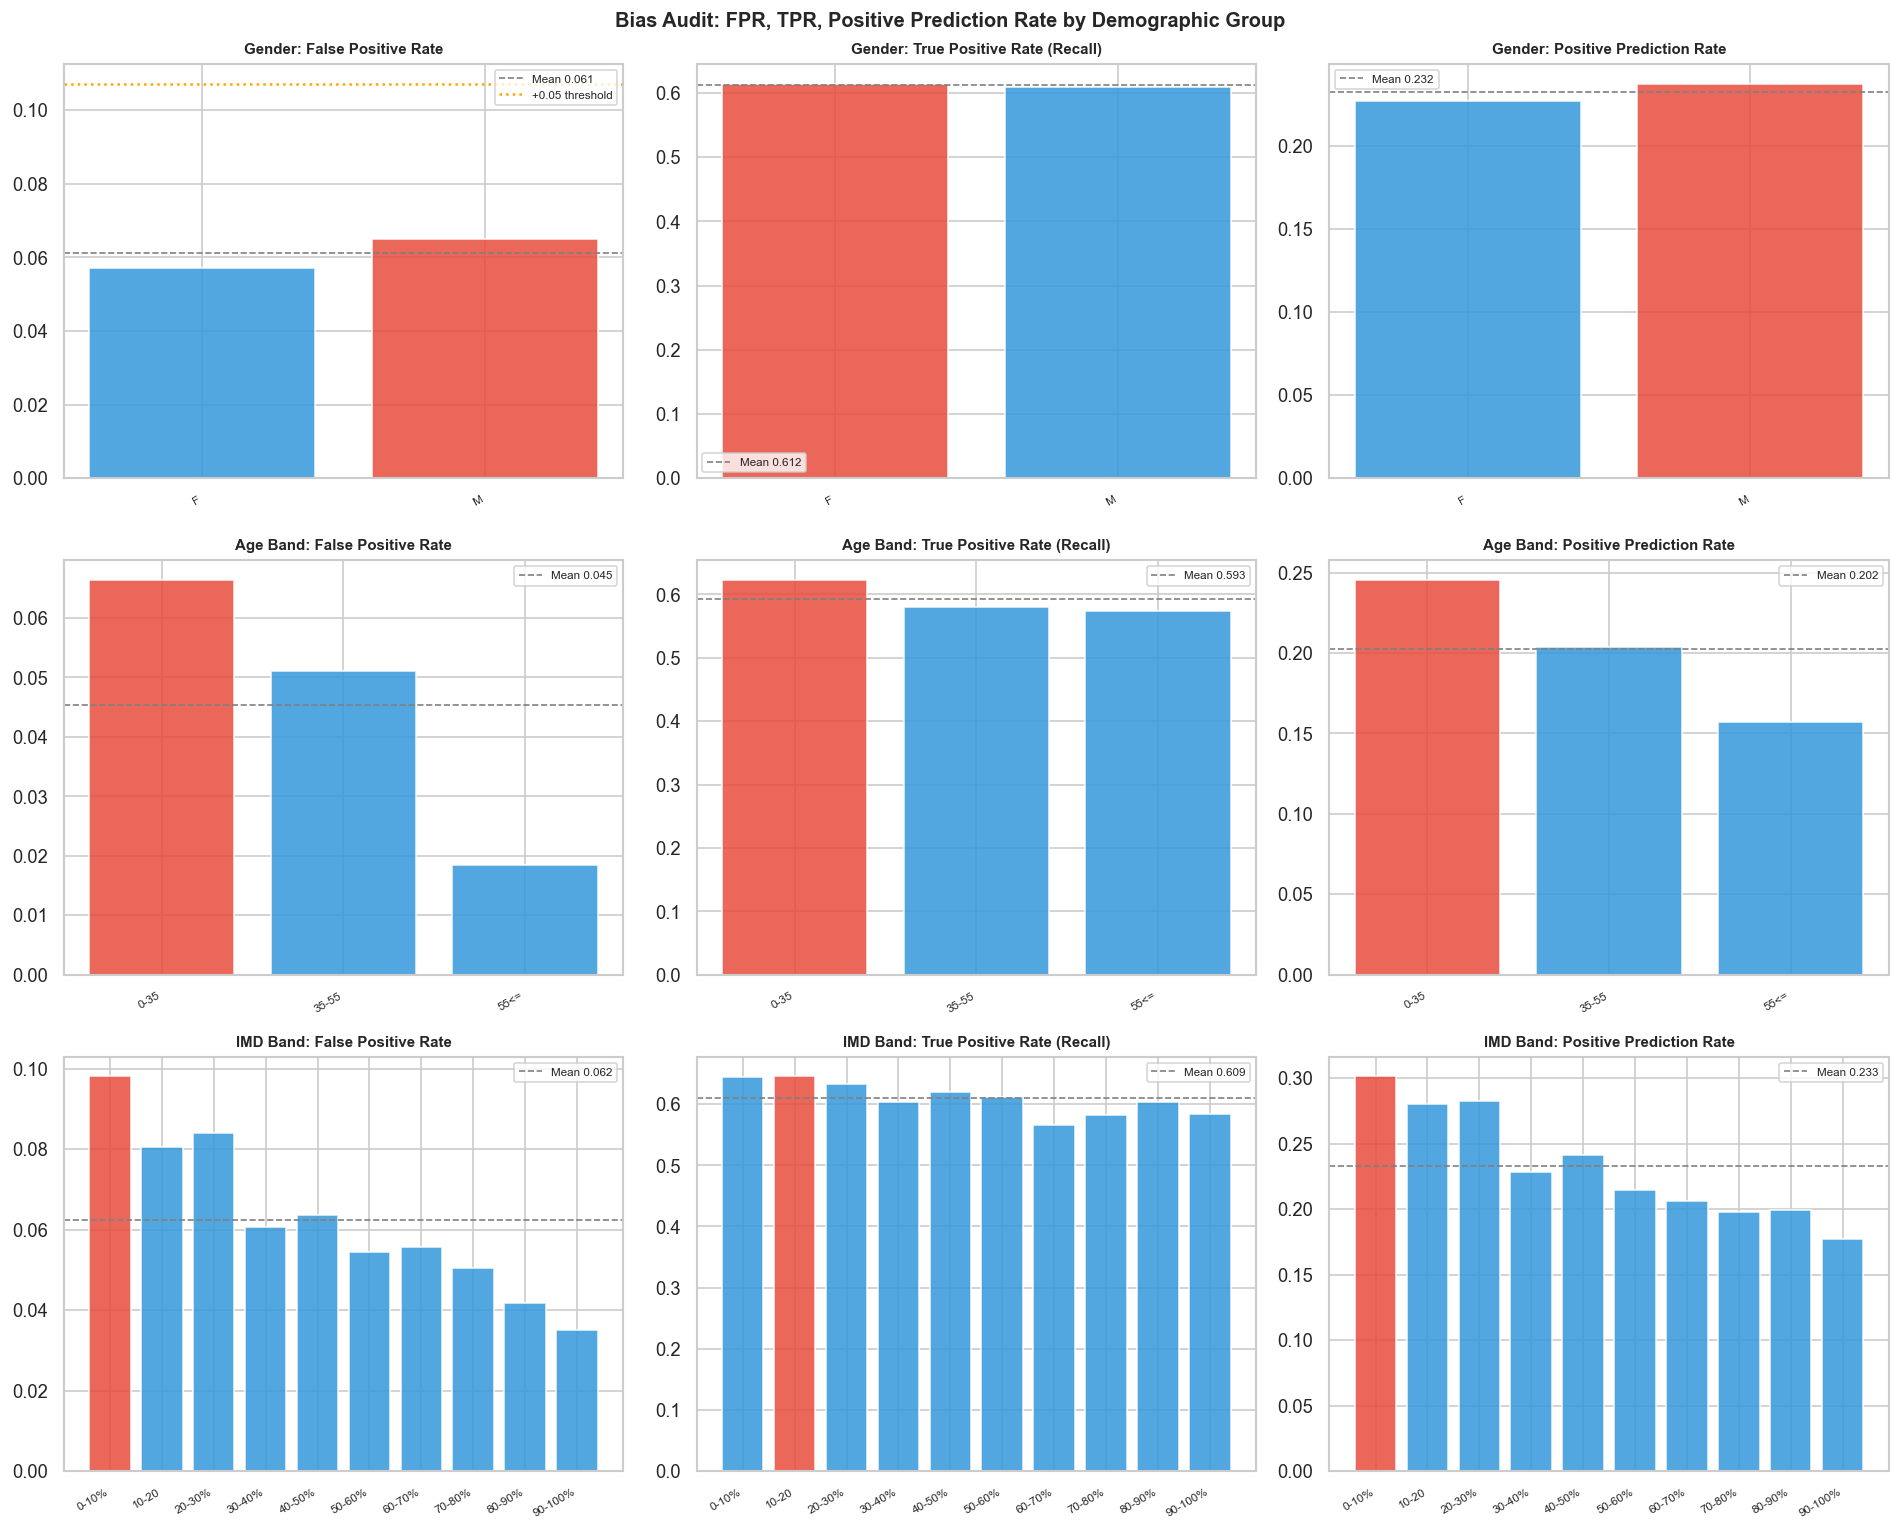

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

for row_idx, (group_col, metrics, label) in enumerate([
    ('gender',  gender_metrics, 'Gender'),
    ('age_band', age_metrics,   'Age Band'),
    ('imd_band', imd_metrics,   'IMD Band'),
]):
    for col_idx, (metric, title, threshold_line) in enumerate([
        ('fpr', 'False Positive Rate', FPR_THRESHOLD),
        ('tpr', 'True Positive Rate (Recall)', None),
        ('ppr', 'Positive Prediction Rate', None),
    ]):
        ax = axes[row_idx][col_idx]
        vals = metrics[metric].dropna()
        colors = ['#e74c3c' if v == vals.max() else '#3498db' for v in vals]
        ax.bar(vals.index, vals.values, color=colors, edgecolor='white', alpha=0.85)
        ax.axhline(vals.mean(), color='gray', linestyle='--', linewidth=1,
                   label=f'Mean {vals.mean():.3f}')
        if threshold_line and row_idx == 0:
            ax.axhline(vals.min() + threshold_line, color='orange', linestyle=':',
                       linewidth=1.5, label=f'+{threshold_line} threshold')
        ax.set_title(f'{label}: {title}', fontweight='bold', fontsize=9)
        ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=7)
        ax.legend(fontsize=7)

plt.suptitle('Bias Audit: FPR, TPR, Positive Prediction Rate by Demographic Group',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## Bias Audit Summary

In [8]:
def audit_summary(metrics, axis, fpr_threshold=FPR_THRESHOLD, di_threshold=DI_THRESHOLD):
    fpr_gap = metrics['fpr'].max() - metrics['fpr'].min()
    tpr_gap = metrics['tpr'].max() - metrics['tpr'].min()
    di = metrics['ppr'].max() / metrics['ppr'].min()
    return {
        'Axis': axis,
        'FPR gap': round(fpr_gap, 4),
        'FPR flagged': fpr_gap > fpr_threshold,
        'TPR gap': round(tpr_gap, 4),
        'DI ratio': round(di, 3),
        'DI flagged': di > di_threshold,
    }

summary = pd.DataFrame([
    audit_summary(gender_metrics, 'Gender'),
    audit_summary(age_metrics,    'Age Band'),
    audit_summary(imd_metrics,    'IMD Band'),
])

print('=== BIAS AUDIT SUMMARY ===')
display(summary.set_index('Axis'))

any_flagged = summary['FPR flagged'].any() or summary['DI flagged'].any()
if any_flagged:
    print('\n⚠️  Disparities detected. See threshold adjustment cell below.')
else:
    print('\n✓ All fairness checks passed within acceptable thresholds.')
    print('Note: finding no bias is a valid result — document it explicitly in model card.')

=== BIAS AUDIT SUMMARY ===


,FPR gap,FPR flagged,TPR gap,DI ratio,DI flagged
Axis,,,,,
Gender,0.0079,False,0.0060,1.046,False
Age Band,0.0479,False,0.0487,1.559,True
IMD Band,0.0630,True,0.0795,1.702,True



⚠️  Disparities detected. See threshold adjustment cell below.


## Threshold Adjustment (if bias detected)

If FPR is higher for a specific group, raise that group's decision threshold to reduce false alarms on retained students. Document before/after metrics.

In [9]:
# This cell applies threshold adjustment per imd_band group if FPR gap > threshold.
# Adjustment: find per-group threshold that equalises FPR to the group with lowest FPR.
# Run only if flagged — otherwise logs "No adjustment needed".

def per_group_threshold_adjust(df, group_col, target_fpr=None):
    """Find per-group probability thresholds that equalise FPR.
    
    target_fpr: FPR to equalise to. Defaults to min FPR across groups.
    Returns dict: {group_value: threshold}
    """
    from numpy import linspace
    thresholds = {}
    df = df.dropna(subset=[group_col])

    if target_fpr is None:
        # Use lowest FPR group as target
        base_metrics = fairness_metrics(df, group_col)
        target_fpr = base_metrics['fpr'].min()

    for group, gdf in df.groupby(group_col, observed=True):
        retained = gdf[gdf['true_label'] == 0]
        if len(retained) == 0:
            thresholds[group] = 0.5
            continue
        # Binary search for threshold that gives FPR closest to target
        best_thresh, best_gap = 0.5, float('inf')
        for t in linspace(0.1, 0.9, 81):
            fp = (retained['risk_score'] / 100 >= t).sum()
            fpr = fp / len(retained)
            gap = abs(fpr - target_fpr)
            if gap < best_gap:
                best_gap, best_thresh = gap, t
        thresholds[group] = round(best_thresh, 3)
    return thresholds


# Run adjustment on imd_band (highest-disparity axis)
imd_fpr_gap = imd_metrics['fpr'].max() - imd_metrics['fpr'].min()

if imd_fpr_gap > FPR_THRESHOLD:
    print(f'IMD FPR gap {imd_fpr_gap:.4f} > {FPR_THRESHOLD} — applying threshold adjustment...')
    adjusted_thresholds = per_group_threshold_adjust(df, 'imd_band')
    print('Adjusted thresholds per IMD band:')
    for k, v in sorted(adjusted_thresholds.items()):
        print(f'  {k}: {v}')

    # Re-evaluate with adjusted thresholds
    df['adjusted_pred'] = df.apply(
        lambda row: int((row['risk_score'] / 100) >= adjusted_thresholds.get(row['imd_band'], 0.5)),
        axis=1
    )
    # Temporarily swap predicted_label column for fairness metrics
    df_adj = df.rename(columns={'predicted_label': '_orig', 'adjusted_pred': 'predicted_label'})
    imd_adj = fairness_metrics(df_adj, 'imd_band')
    df.rename(columns={'predicted_label': 'adjusted_pred', '_orig': 'predicted_label'}, inplace=True)

    print('\nIMD FPR BEFORE adjustment:')
    print(imd_metrics[['fpr', 'tpr', 'ppr']].to_string())
    print('\nIMD FPR AFTER adjustment:')
    print(imd_adj[['fpr', 'tpr', 'ppr']].to_string())
    print(f'\nGap after: {imd_adj["fpr"].max() - imd_adj["fpr"].min():.4f}')
else:
    print(f'IMD FPR gap {imd_fpr_gap:.4f} ≤ {FPR_THRESHOLD} — no adjustment needed. ✓')

IMD FPR gap 0.0630 > 0.05 — applying threshold adjustment...
Adjusted thresholds per IMD band:
  0-10%: 0.78
  10-20: 0.76
  20-30%: 0.76
  30-40%: 0.68
  40-50%: 0.66
  50-60%: 0.62
  60-70%: 0.7
  70-80%: 0.63
  80-90%: 0.58
  90-100%: 0.5



IMD FPR BEFORE adjustment:
            fpr     tpr     ppr
group                          
0-10%    0.0981  0.6450  0.3014
10-20    0.0806  0.6453  0.2807
20-30%   0.0840  0.6336  0.2827
30-40%   0.0606  0.6027  0.2283
40-50%   0.0637  0.6200  0.2417
50-60%   0.0544  0.6118  0.2148
60-70%   0.0557  0.5658  0.2065
70-80%   0.0504  0.5822  0.1976
80-90%   0.0418  0.6034  0.1991
90-100%  0.0351  0.5838  0.1771

IMD FPR AFTER adjustment:
            fpr     tpr     ppr
group                          
0-10%    0.0361  0.4744  0.1990
10-20    0.0352  0.5217  0.2076
20-30%   0.0347  0.4868  0.1981
30-40%   0.0360  0.5151  0.1842
40-50%   0.0348  0.5499  0.1996
50-60%   0.0351  0.5484  0.1828
60-70%   0.0342  0.4680  0.1625
70-80%   0.0355  0.5119  0.1674
80-90%   0.0352  0.5646  0.1836
90-100%  0.0351  0.5838  0.1771

Gap after: 0.0019


## Proxy Feature Check

Do any engineered features act as proxies for protected attributes? Check correlation between imd_band_num and financial_hold_flag (synthetic — by design correlated with outcome, not demographics).

In [10]:
X_full = pd.read_csv('../data/processed/feature_matrix.csv')
info_full = pd.read_csv('../data/raw/studentInfo.csv',
                        usecols=['code_module', 'code_presentation', 'id_student', 'imd_band'])

imd_order = {
    '0-10%': 1, '10-20%': 2, '20-30%': 3, '30-40%': 4, '40-50%': 5,
    '50-60%': 6, '60-70%': 7, '70-80%': 8, '80-90%': 9, '90-100%': 10,
}
info_full['imd_num'] = info_full['imd_band'].map(imd_order)

proxy_check = X_full.merge(info_full[['code_module', 'code_presentation', 'id_student', 'imd_num']],
                           on=['code_module', 'code_presentation', 'id_student'], how='left')

key_features = ['financial_hold_flag', 'credit_overload_flag', 'days_since_last_vle',
                'total_clicks_w6', 'submission_rate_w6', 'avg_score_w6']

proxy_corrs = proxy_check[key_features].corrwith(proxy_check['imd_num']).round(4)
print('Correlation of key features with IMD band (proxy check):')
print(proxy_corrs.to_string())
print()
HIGH_PROXY = proxy_corrs.abs() > 0.3
if HIGH_PROXY.any():
    print(f'⚠️  High proxy correlations (|r| > 0.3): {proxy_corrs[HIGH_PROXY].to_dict()}')
else:
    print('✓ No features are strong proxies for IMD band (|r| ≤ 0.3).')

Correlation of key features with IMD band (proxy check):
financial_hold_flag    -0.0190
credit_overload_flag    0.0049
days_since_last_vle    -0.0900
total_clicks_w6         0.0634
submission_rate_w6      0.0981
avg_score_w6            0.0626

✓ No features are strong proxies for IMD band (|r| ≤ 0.3).
